In [3]:
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sys
print(sys.executable)
print("cupy", cp.__version__)
print("scanpy", sc.__version__)
print("GPU count:", cp.cuda.runtime.getDeviceCount())
print(cp.arange(10).sum())

/home/users/z/zhouji/.conda/envs/rsc-gpu/bin/python
cupy 14.1.1
scanpy 1.12.2
GPU count: 2


/tmp/ipykernel_1246553/420825688.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


45


In [5]:
import anndata as ad

In [10]:
adata_no_doublet = ad.read_h5ad("adata_no_doublet.h5ad")

In [11]:
adata_no_doublet.uns.get("log1p", None)

{'base': None}

In [14]:
print(cp.cuda.runtime.getDeviceCount())

2


In [4]:
from dask_cuda import LocalCUDACluster
from dask.distributed import Client

cluster = LocalCUDACluster(CUDA_VISIBLE_DEVICES="0,1")
client = Client(cluster)
client

2026-07-03 10:06:14 | [INFO] To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-07-03 10:06:14 | [INFO] State start
2026-07-03 10:06:14 | [INFO]   Scheduler at:     tcp://127.0.0.1:45039
2026-07-03 10:06:14 | [INFO]   dashboard at:  http://127.0.0.1:8787/status
2026-07-03 10:06:14 | [INFO] Registering Worker plugin shuffle
2026-07-03 10:06:14 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:35813'
2026-07-03 10:06:14 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:36879'
2026-07-03 10:06:17 | [INFO] Register worker addr: tcp://127.0.0.1:46365 name: 1
2026-07-03 10:06:17 | [INFO] Starting worker compute stream, tcp://127.0.0.1:46365
2026-07-03 10:06:17 | [INFO] Starting established connection to tcp://127.0.0.1:40136
2026-07-03 10:06:17 | [INFO] Register worker addr: tcp://127.0.0.1:33231 name: 0
2026-07-03 10:06:17 | [INFO] Starting worker compute stream, tcp://127.0.0.1:33231
2026-07-03 10:06:17 | [INFO] S

Connection method: Cluster object,Cluster type: dask_cuda.LocalCUDACluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45039,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33231,Total threads: 1
Dashboard: http://127.0.0.1:38467/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:35813,


2026-07-03 10:09:42 | [INFO] Event loop was unresponsive in Nanny for 3.15s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-07-03 10:09:42 | [INFO] Event loop was unresponsive in Nanny for 3.14s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-07-03 10:09:42 | [INFO] Event loop was unresponsive in Scheduler for 3.13s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-07-03 10:44:23 | [INFO] Closing Nanny gracefully at 'tcp://127.0.0.1:35813'. Reason: worker-close
2026-07-03 10:44:23 | [INFO] Received 'close-stream' from tcp://127.0.0.1:40138; closing.
2026-07-03 10:44:23 | [INFO] Closing Nanny gracefully at 'tcp://127.0.0.1:36879'. Reason: worker-close
2026-07-03 10:44:23 | [INFO] Received 'close-stream' from tcp://127.0.

In [16]:
client.scheduler_info()["workers"].keys()

dict_keys(['tcp://127.0.0.1:33363', 'tcp://127.0.0.1:39981'])

In [5]:
import zarr
from anndata.experimental import read_elem_lazy

In [6]:
!pwd

/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc


In [19]:
zarr_path = "adata_no_doublet.zarr"
ad.read_h5ad("adata_no_doublet.h5ad").write_zarr(zarr_path)

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/zarr.py:44: UserWarning: Writing zarr v2 data will no longer be the default in the next minor release. v3 data will be written by default. If you are explicitly setting this configuration, consider migrating to the zarr v3 file format.
  f = open_write_group(store)


In [20]:
store = zarr.open(zarr_path)
shape = store["X"].attrs["shape"]

X_lazy = read_elem_lazy(store["X"], chunks=(50_000, shape[1]))

adata = ad.AnnData(
    X=X_lazy,
    obs=ad.io.read_elem(store["obs"]),
    var=ad.io.read_elem(store["var"]),
)

In [21]:
rsc.get.anndata_to_GPU(adata)
adata.X = adata.X.persist()
adata.X.compute_chunk_sizes()

dask.array<X_to_GPU, shape=(1111574, 36910), dtype=float32, chunksize=(50000, 36910), chunktype=cupyx.csr_matrix>

In [22]:
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
adata.X = adata.X.persist()
adata.X.compute_chunk_sizes()

dask.array<_calc_log1p, shape=(1111574, 36910), dtype=float32, chunksize=(50000, 36910), chunktype=cupyx.csr_matrix>

In [23]:
rsc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    flavor="cell_ranger",
)

In [24]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [25]:
n_workers = len(client.scheduler_info()["workers"])
n_rows, n_cols = adata.shape
rows_per_worker = (n_rows + n_workers - 1) // n_workers

In [26]:
adata.X = adata.X.rechunk((rows_per_worker, n_cols)).persist()
adata.X.compute_chunk_sizes()

dask.array<rechunk-merge, shape=(1111574, 5000), dtype=float32, chunksize=(555787, 5000), chunktype=cupyx.csr_matrix>

In [27]:
rsc.pp.scale(adata, zero_center=False)
adata.X = adata.X.persist()
adata.X.compute_chunk_sizes()

dask.array<scale_kernel_csr, shape=(1111574, 5000), dtype=float32, chunksize=(555787, 5000), chunktype=cupyx.csr_matrix>

In [28]:
rsc.pp.pca(adata, n_comps=100, mask_var=None)
adata.obsm["X_pca"] = adata.obsm["X_pca"].persist()
adata.obsm["X_pca"].compute_chunk_sizes()

dask.array<_transform, shape=(1111574, 100), dtype=float32, chunksize=(555787, 100), chunktype=cupy.ndarray>

In [29]:
adata.obsm["X_pca"] = adata.obsm["X_pca"].compute()

In [33]:
rsc.pp.neighbors(
    adata,
    n_neighbors=50,
    n_pcs=50,
    algorithm="all_neighbors",  # multi-GPU/out-of-core friendly
)

rsc.tl.umap(adata)
rsc.tl.leiden(adata, resolution=1.0)

In [37]:
for res in [0.07, 0.5, 1]:
    rsc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res)

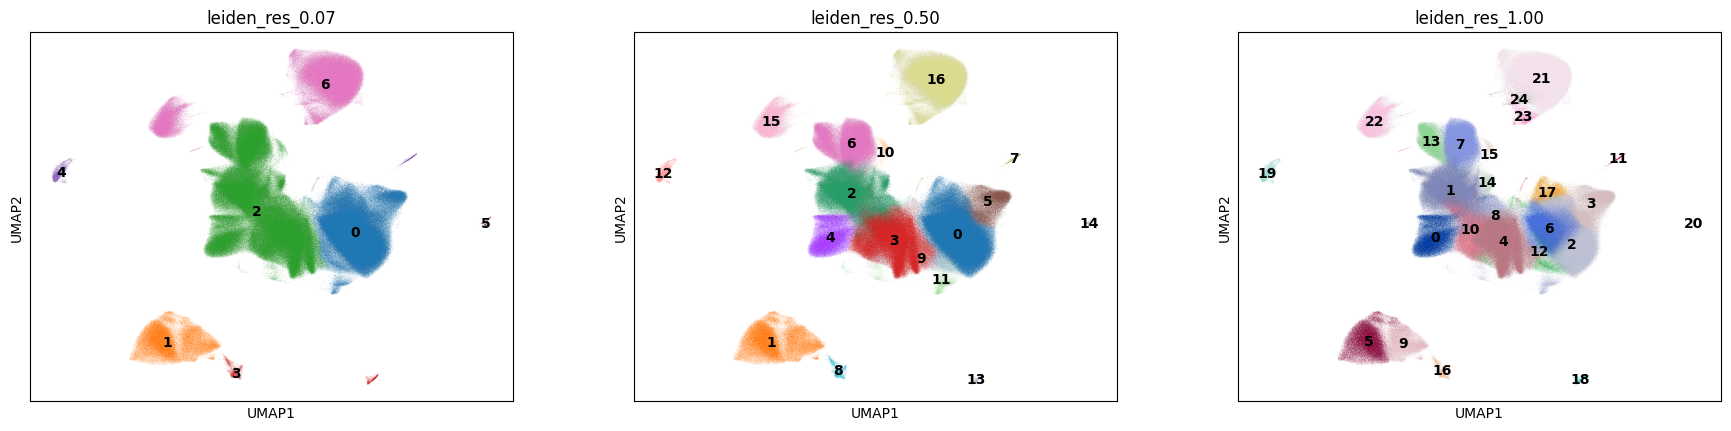

In [38]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.07", "leiden_res_0.50", "leiden_res_1.00"],
    legend_loc="on data",
)

In [46]:
adata.X

dask.array<scale_kernel_csr, shape=(1111574, 5000), dtype=float32, chunksize=(555787, 5000), chunktype=cupyx.csr_matrix>

In [47]:
if hasattr(adata.obsm.get("X_pca", None), "compute"):
    adata.obsm["X_pca"] = adata.obsm["X_pca"].compute()

if hasattr(adata.obsm.get("X_umap", None), "compute"):
    adata.obsm["X_umap"] = adata.obsm["X_umap"].compute()

In [48]:
rsc.get.anndata_to_CPU(adata)

In [49]:
adata.write_h5ad("adata_gpu_5000hvg_umap_leiden.h5ad")

In [6]:
adata = ad.read_h5ad("adata_gpu_5000hvg_umap_leiden.h5ad")

In [7]:
adata_full = ad.read_h5ad("adata_no_doublet.h5ad")

In [8]:
adata_full.obs["leiden"] = adata.obs["leiden"].values
adata_full.obs["leiden_res_0.07"] = adata.obs["leiden_res_0.07"].values
adata_full.obs["leiden_res_0.50"] = adata.obs["leiden_res_0.50"].values
adata_full.obs["leiden_res_1.00"] = adata.obs["leiden_res_1.00"].values

adata_full.obsm["X_umap"] = adata.obsm["X_umap"]

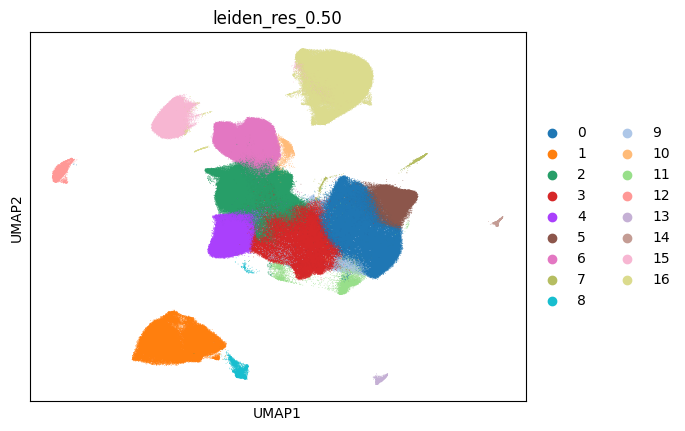

In [9]:
sc.pl.umap(adata_full, color=["leiden_res_0.50"], size=1)

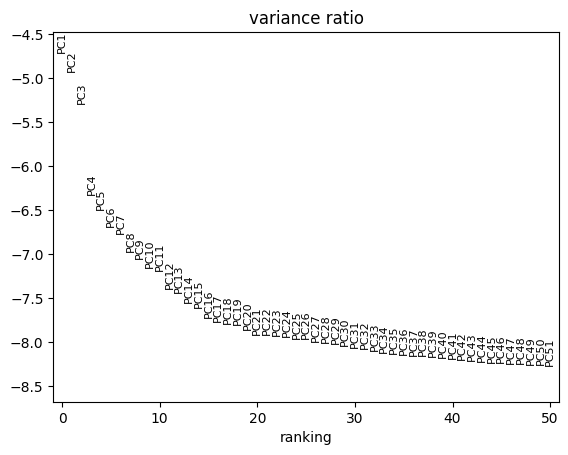

In [10]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

2026-07-09 10:23:30 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-09 10:23:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-09 10:23:32 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-09 10:23:35 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-09 10:23:36 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

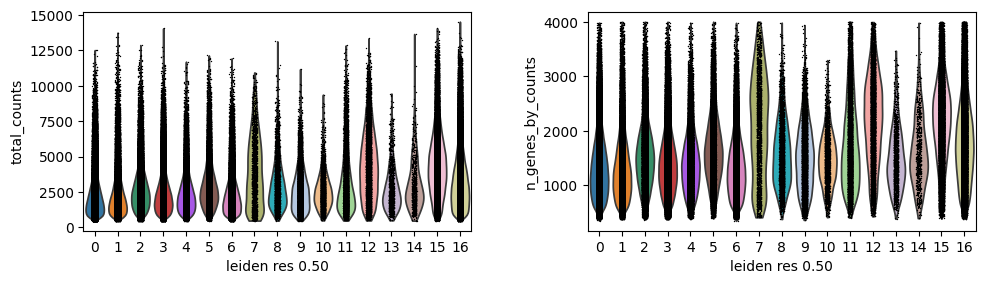

In [11]:
from matplotlib import rc_context

with rc_context({"figure.figsize": (5, 3)}):
    sc.pl.violin(adata_full, ["total_counts", "n_genes_by_counts"], groupby="leiden_res_0.50")

In [12]:
marker_genes = {
    "Mono": ["CTSS", "FCN1", "LYZ", "PSAP", "S100A9", "AIF1", "MNDA", "SERPINA1", "TYROBP"],
    "CD4+ T": ["IL7R", "MAL", "LTB", "CD4", "LDHB", "TRAC", "TMSB10", "CD3D", "CD3G"],
    "CD8+ T": ["CD8B", "CD8A", "CD3D", "TMSB10", "HCST", "CD3G", "LINC02446", "CTSW", "CD3E", "TRAC"],
    "NK": ["NKG7", "KLRD1", "TYROBP", "GNLY", "FCER1G", "PRF1", "KLRF1", "CST7", "GZMB"],
    "B cells": ["CD79A", "RALGPS2", "CD79B", "MS4A1", "BANK1", "TNFRSF13C", "HLA-DQA1", "IGHM"],
    "DC": ["CD74", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "CCDC88A", "HLA-DRA", "HLA-DMA", "CST3", "HLA-DQB1", "HLA-DRB1"],
    "unconventional T": ["CD3D", "TRDC", "GZMK", "KLRB1", "NKG7", "TRGC2", "CST7", "LYAR", "KLRG1", "GZMA"],
    "Eryth": ["HBD", "HBM", "AHSP", "ALAS2", "CA1", "SLC4A1", "IFIT1B", "TRIM58", "SELENBP1", "TMCC2"],
    "HSPC": ["SPINK2", "PRSS57", "CYTL1", "EGFL7", "GATA2", "CD34", "SMIM24", "AVP", "MYB", "LAPTM4B"],
    "ILC": ["KIT", "TRDC", "TTLL10", "LINC01229", "SOX4", "KLRB1", "TNFRSF18", "TNFRSF4", "IL1R1", "HPGDS"],
    "Platelet": ["PPBP", "PF4", "NRGN", "GNG11", "CAVIN2", "TUBB1", "CLU", "RGS18", "GP9"]
}

/tmp/ipykernel_1183453/1773871011.py:1: UserWarning: You’re trying to run this on 36910 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pl.dotplot(adata_full, marker_genes, groupby="leiden_res_0.50", standard_scale="var", dendrogram=True)


categories: 0, 1, 2, etc.
var_group_labels: Mono, CD4+ T, CD8+ T, etc.


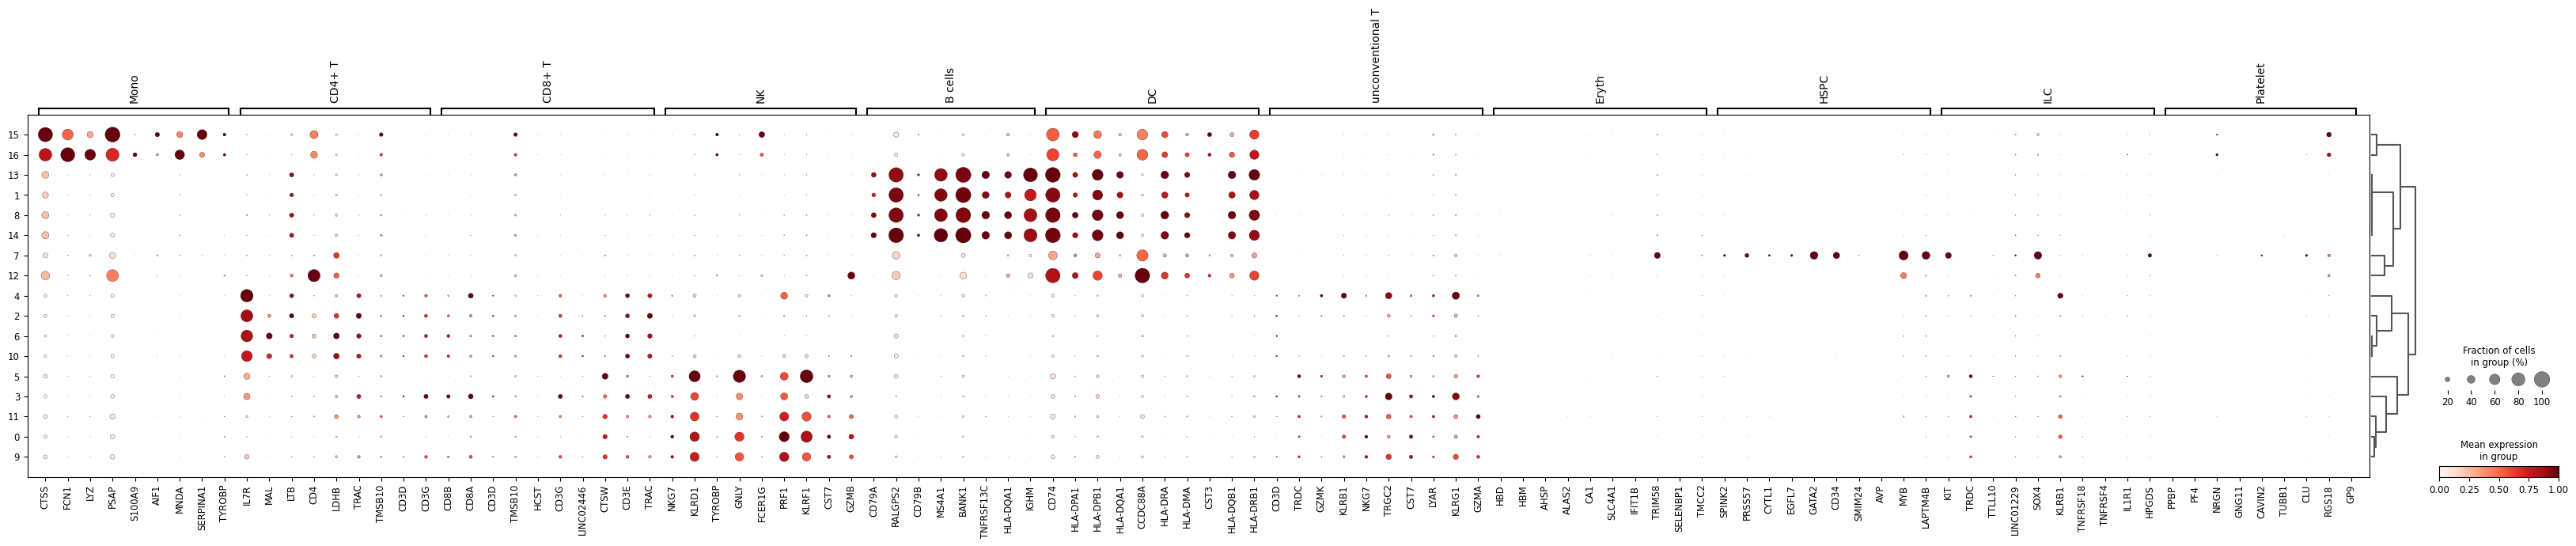

In [13]:
sc.pl.dotplot(adata_full, marker_genes, groupby="leiden_res_0.50", standard_scale="var", dendrogram=True)

In [14]:
# keep only genes present in the object
score_cols = []

for celltype, genes in marker_genes.items():
    genes_present = [g for g in genes if g in adata_full.var_names]

    print(celltype, ":", len(genes_present), "/", len(genes), "genes found")

    score_name = f"{celltype}_score"
    score_cols.append(score_name)

    sc.tl.score_genes(
        adata_full,
        gene_list=genes_present,
        score_name=score_name,
        use_raw=False,
    )

Mono : 9 / 9 genes found
CD4+ T : 9 / 9 genes found
CD8+ T : 10 / 10 genes found
NK : 9 / 9 genes found
B cells : 8 / 8 genes found
DC : 10 / 10 genes found
unconventional T : 10 / 10 genes found
Eryth : 10 / 10 genes found
HSPC : 10 / 10 genes found
ILC : 10 / 10 genes found
Platelet : 9 / 9 genes found


In [15]:
score_by_cluster = (
    adata_full.obs
    .groupby("leiden_res_0.50", observed=True)[score_cols]
    .mean()
)

score_by_cluster

,Mono_score,CD4+ T_score,CD8+ T_score,NK_score,B cells_score,DC_score,unconventional T_score,Eryth_score,HSPC_score,ILC_score,Platelet_score
leiden_res_0.50,,,,,,,,,,,
0,-0.147662,-0.274657,-0.010902,0.377624,-0.060220,-0.285801,0.033257,0.000091,-0.001375,0.014086,-0.008665
1,-0.127165,-0.184187,-0.060469,-0.199677,1.370879,0.466147,-0.116209,0.002491,-0.004428,-0.024149,-0.009281
2,-0.204551,0.112233,0.064312,-0.217253,-0.070806,-0.259182,-0.055578,0.000223,0.000088,-0.014123,-0.008729
3,-0.175960,-0.110868,0.127240,0.059965,-0.076866,-0.237569,0.099904,0.000305,-0.001904,-0.004239,-0.009353
4,-0.190276,0.031267,0.081860,-0.109517,-0.045518,-0.275814,0.113147,0.000629,0.002237,0.027940,-0.007762
5,-0.188115,-0.220834,-0.005038,0.373657,-0.056047,-0.261997,0.010452,0.002713,-0.000846,0.033475,-0.010302
6,-0.188447,0.196800,0.076601,-0.211323,-0.045837,-0.248684,-0.101050,0.000086,0.004389,-0.024754,-0.010086
7,-0.136746,-0.213665,-0.094416,-0.223927,-0.001143,0.080323,-0.142810,0.040255,0.311013,0.089330,0.007838
8,-0.136303,-0.193176,-0.062914,-0.214056,1.397756,0.509810,-0.126173,0.003322,-0.004704,-0.025837,-0.010687


In [16]:
import seaborn as sns

Text(0.5, 1.02, 'Mean marker score by cluster')

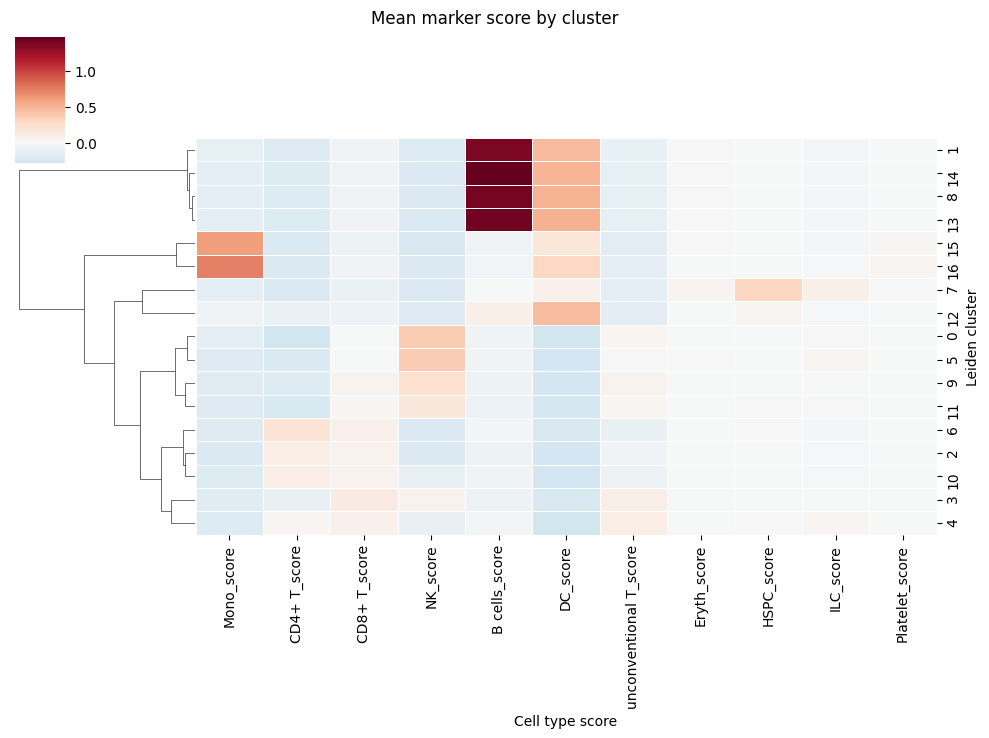

In [17]:
g = sns.clustermap(
    score_by_cluster,
    cmap="RdBu_r",
    center=0,
    row_cluster=True,
    col_cluster=False,
    linewidths=0.5,
    figsize=(10, 7)
)

g.ax_heatmap.set_xlabel("Cell type score")
g.ax_heatmap.set_ylabel("Leiden cluster")
g.fig.suptitle("Mean marker score by cluster", y=1.02)

In [18]:
marker_genes_3 = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14", "LTB"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3","CDK6", "SYNGR1", "HBM", "GYPA"],
]

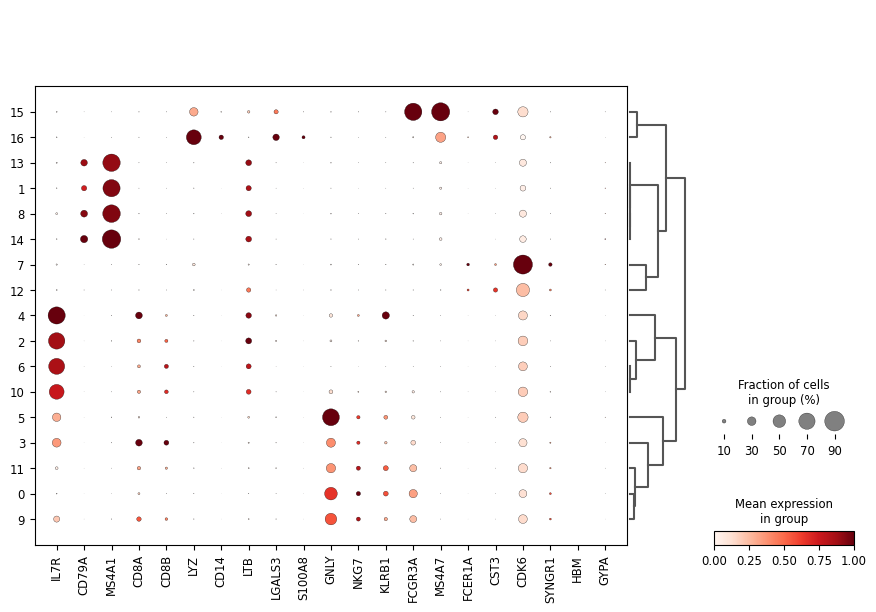

In [19]:
sc.pl.dotplot(adata_full, marker_genes_3, groupby="leiden_res_0.50", standard_scale="var", dendrogram=True)

In [20]:
marker_genes_2 = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [21]:
# keep only genes present in the object
score_cols_2 = []

for celltype, genes in marker_genes.items():
    genes_present = [g for g in genes if g in adata_full.var_names]

    print(celltype, ":", len(genes_present), "/", len(genes), "genes found")

    score_name = f"{celltype}_score"
    score_cols.append(score_name)

    sc.tl.score_genes(
        adata_full,
        gene_list=genes_present,
        score_name=score_name,
        use_raw=False,
    )

Mono : 9 / 9 genes found
CD4+ T : 9 / 9 genes found
CD8+ T : 10 / 10 genes found
NK : 9 / 9 genes found
B cells : 8 / 8 genes found
DC : 10 / 10 genes found
unconventional T : 10 / 10 genes found
Eryth : 10 / 10 genes found
HSPC : 10 / 10 genes found
ILC : 10 / 10 genes found
Platelet : 9 / 9 genes found


categories: 0, 1, 2, etc.
var_group_labels: CD14+ Mono, CD16+ Mono, cDC2, etc.


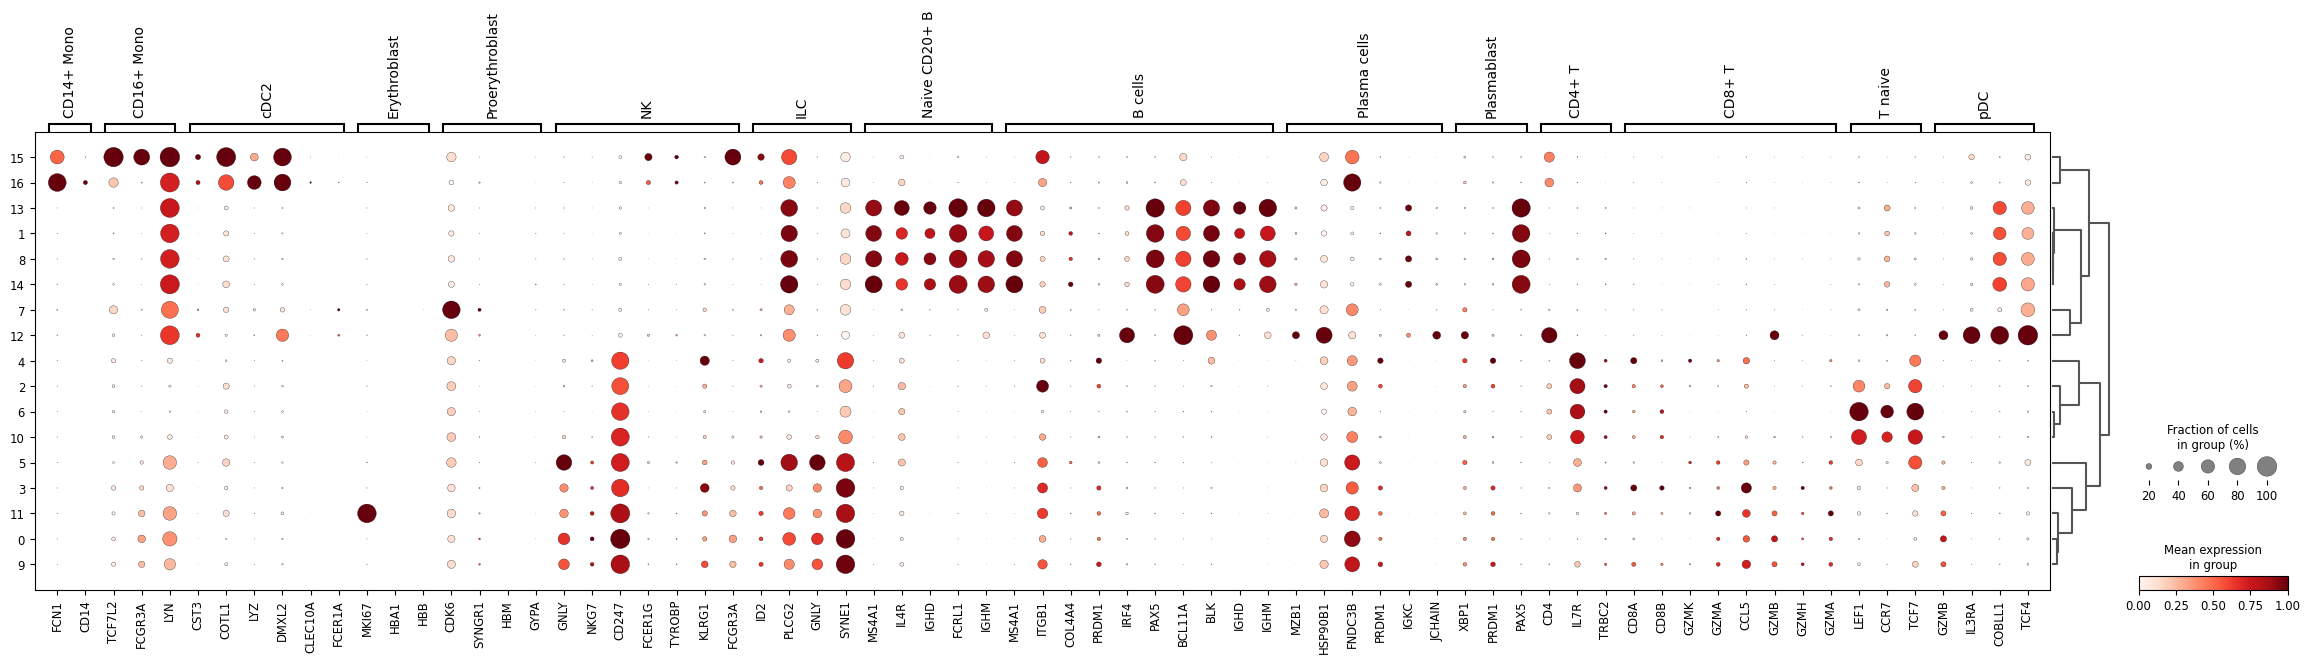

In [22]:
sc.pl.dotplot(adata_full, marker_genes_2, groupby="leiden_res_0.50", standard_scale="var", dendrogram=True)

In [ ]:
adata_full.write_h5ad("adata_no_doublet_withanno.h5ad")

2026-07-03 10:44:25,625 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/asyncio/runners.py", line 119, in run
    return self._loop.run_until_complete(task)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/asyncio/base_events.py", line 725, in run_until_complete
    return future.result()
           ~~~~~~~~~~~~~^^
  File "/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/asyncio/locks.py", line 213, in wait
    await fut
as

In [23]:
!pwd

/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc


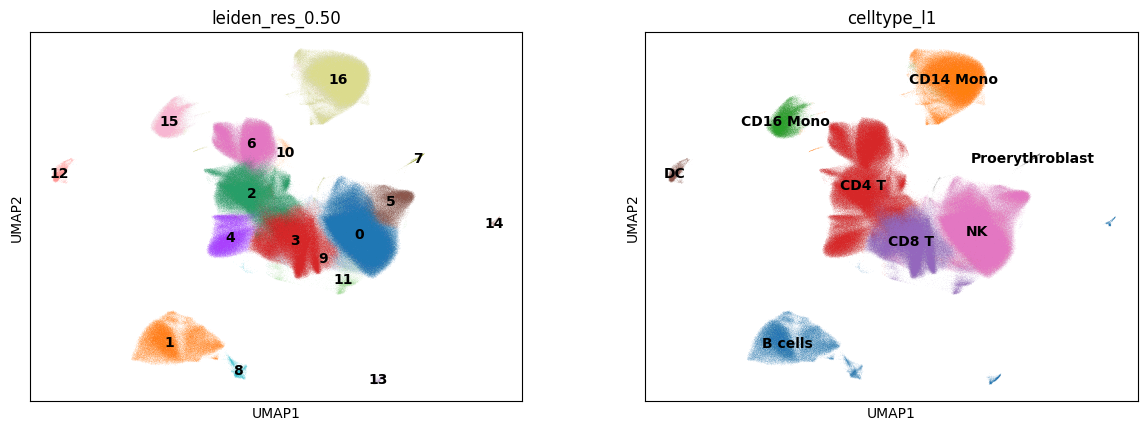

In [24]:
celltype_map = {
    "0": "NK",
    "1": "B cells",
    "2": "CD4 T",
    "3": "CD8 T",
    "4": "CD4 T",
    "5": "NK",
    "6": "CD4 T",
    "7": "Proerythroblast",
    "8": "B cells",
    "9": "NK",
    "10": "CD4 T",
    "11": "CD8 T",
    "12": "DC",
    "13": "B cells",
    "14": "B cells",
    "15": "CD16 Mono",
    "16": "CD14 Mono",
}

adata_full.obs["celltype_l1"] = (
    adata_full.obs["leiden_res_0.50"]
    .astype(str)
    .map(celltype_map)
    .astype("category")
)

sc.pl.umap(
    adata_full,
    color=["leiden_res_0.50", "celltype_l1"],
    legend_loc="on data",
)

In [25]:
import pandas as pd
import numpy as np

In [26]:
meta_path = "data/Oct25-22q11-ScaleBio_Metadata.xlsx"

meta = pd.read_excel(meta_path, sheet_name="Samples + Barcodes")

# keep real sample rows
meta = meta.dropna(subset=["Added oligo well "]).copy()

# clean column names
meta = meta.rename(columns={
    "SampleID": "sample_id",
    "Barcode": "barcode",
    "Sample Type": "sample_type",
    "Sample Name": "sample_name",
    "Description": "diagnosis",
    "Participant ID": "participant_id",
    "Participant age at collection": "age",
    "Participant sex": "sex",
    "Ethnic origin": "ethnic_origin",
    "Added oligo well ": "oligo_well",
    "Link to a 22q participant": "linked_22q_id"
})

In [27]:
meta["disease_group"] = np.where(
    meta["diagnosis"].astype(str).str.contains("22q", case=False, na=False),
    "Patient",
    "Non-patient"
)

In [28]:
meta

,Unnamed: 0,Date of fixation,Unnamed: 2,sample_id,barcode,sample_type,sample_name,diagnosis,participant_id,age,sex,ethnic_origin,linked_22q_id,Type of relationship (22q participant is the …),oligo_well,Pool Barcode,Cell concentration/Volume,disease_group
0,Round 1 (was re-done) = Sample 1,"Friday, 10.10.25, PM",1.0,11239027.0,FR31148252,SMH Biobank_PBMC,SMHB_02_00001_PBMC 3,LD44.N0 (22q11DS),5667/01,30.00,F,Caucasian,NaN,NaN,B12,CS2560,7500 cells/µl (80 µl total),Patient
1,NaN,NaN,2.0,11243928.0,FR31147867,SMH Biobank_PBMC,SMHB_02_00002_PBMC 2,LD44.N0 (22q11DS),5944/01,26.00,M,Caucasian,NaN,NaN,C12,NaN,NaN,Patient
2,NaN,NaN,3.0,11249610.0,FR31148466,SMH Biobank_PBMC,SMHB_02_00003_PBMC 2,LD44.N0 (22q11DS),5143/01,29.00,F,Caucasian,NaN,NaN,D12,NaN,NaN,Patient
3,NaN,NaN,4.0,11254239.0,FR31148194,SMH Biobank_PBMC,SMHB_02_00005_PBMC 2,LD44.N0 (22q11DS),7545/01,17.00,M,Caucasian,NaN,NaN,E12,NaN,NaN,Patient
4,NaN,NaN,5.0,11298873.0,FR31147945,SMH Biobank_PBMC,SMHB_02_00006_PBMC 2,LD44.N0 (22q11DS),6298/01,24.00,F,Caucasian,NaN,NaN,F12,NaN,NaN,Patient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,NaN,NaN,76.0,11571933.0,FR31148151,SMH Biobank_PBMC,SMHB_02_00070_PBMC 2,No disease reported,8192/01,21.01,F,Caucasian,8191/01,sister,H6,NaN,NaN,Non-patient
83,NaN,NaN,77.0,11582310.0,FR31148176,SMH Biobank_PBMC,SMHB_02_00072_PBMC 1,No disease reported,7745/01,14.00,M,Caucasian,7744/01,brother,H7,NaN,NaN,Non-patient
84,NaN,NaN,78.0,11589447.0,FR31147839,SMH Biobank_PBMC,SMHB_02_00074_PBMC 1,No disease reported,6568/01,21.10,F,Caucasian,5686/01,sister,H8,NaN,NaN,Non-patient
85,NaN,NaN,79.0,11595762.0,FR31147710,SMH Biobank_PBMC,SMHB_02_00076_PBMC 1,No disease reported,8398/02,60.00,M,Caucasian,8398/01,daughter,H9,NaN,NaN,Non-patient


In [29]:
meta["pair_id"] = np.where(
    meta["disease_group"] == "Patient",
    meta["participant_id"],
    meta["linked_22q_id"]
)

In [30]:
meta["pair_id"].value_counts()

pair_id
6472/01    5
6298/01    4
8361/01    4
8380/01    4
8368/01    3
8395/01    3
7497/01    3
8354/01    3
8398/01    3
6489/01    3
8191/01    2
7744/01    2
8370/01    2
7405/01    2
5143/01    2
8150/01    2
5686/01    2
7487/01    2
8145/01    2
6977/01    2
5740/01    2
7888/01    2
8119/01    2
5884/01    2
7805/01    2
5667/01    1
5944/01    1
7545/01    1
7843/01    1
5961/01    1
5856/01    1
6343/01    1
7627/01    1
7700/01    1
7347/01    1
5924/01    1
7614/01    1
6032/01    1
6608/01    1
8509/01    1
Name: count, dtype: int64

In [33]:
# convert B12 -> 12B, C12 -> 12C, etc.
import re

def well_to_scaleplex(x):
    x = str(x).strip()
    m = re.match(r"^([A-H])(\d{1,2})$", x)
    if m is None:
        return pd.NA
    row, col = m.groups()
    return f"{col}{row}"

In [34]:
meta["assigned_scaleplex"] = meta["oligo_well"].map(well_to_scaleplex)

In [35]:
print("metadata samples:", meta["assigned_scaleplex"].nunique())
print("adata samples:", adata_full.obs["assigned_scaleplex"].nunique())

print(
    "in adata not metadata:",
    set(adata_full.obs["assigned_scaleplex"].astype(str)) - set(meta["assigned_scaleplex"].astype(str))
)

print(
    "in metadata not adata:",
    set(meta["assigned_scaleplex"].astype(str)) - set(adata_full.obs["assigned_scaleplex"].astype(str))
)

metadata samples: 80
adata samples: 80
in adata not metadata: set()
in metadata not adata: set()


In [36]:
adata_full.obs = (
    adata_full.obs
    .reset_index()
    .merge(meta, on="assigned_scaleplex", how="left")
    .set_index("index")
)

adata_full.obs.index.name = None

In [37]:
adata_full.obs.columns.tolist()

['counts',
 'genes',
 'totalReads',
 'countedReads',
 'mappedReads',
 'geneReads',
 'exonReads',
 'intronReads',
 'antisenseReads',
 'mitoReads',
 'countedMultiGeneReads',
 'Saturation',
 'mitoProp',
 'PCR',
 'RT',
 'bead_bc',
 'sample',
 'flags',
 'passing_scaleplex',
 'assigned_scaleplex',
 'sample_group',
 'n_genes_by_counts',
 'total_counts',
 'total_counts_mt',
 'pct_counts_mt',
 'total_counts_ribo',
 'pct_counts_ribo',
 'total_counts_hb',
 'pct_counts_hb',
 'n_genes',
 'doublet_score',
 'predicted_doublet',
 'leiden',
 'leiden_res_0.07',
 'leiden_res_0.50',
 'leiden_res_1.00',
 'Mono_score',
 'CD4+ T_score',
 'CD8+ T_score',
 'NK_score',
 'B cells_score',
 'DC_score',
 'unconventional T_score',
 'Eryth_score',
 'HSPC_score',
 'ILC_score',
 'Platelet_score',
 'celltype_l1',
 'Unnamed: 0',
 'Date of fixation',
 'Unnamed: 2',
 'sample_id',
 'barcode',
 'sample_type',
 'sample_name',
 'diagnosis',
 'participant_id',
 'age',
 'sex',
 'ethnic_origin',
 'linked_22q_id',
 'Type of relati

In [38]:
adata_full.obs[[
    "assigned_scaleplex",
    "diagnosis",
    "participant_id",
    "age",
    "sex"
]].head()

,assigned_scaleplex,diagnosis,participant_id,age,sex
QSR-1+06+68+03+5C,12E,LD44.N0 (22q11DS),7545/01,17.0,M
QSR-1+06+49+39+5C,11B,LD44.N0 (22q11DS),7843/01,20.0,M
QSR-1+06+24+93+5C,12C,LD44.N0 (22q11DS),5944/01,26.0,M
QSR-1+06+47+63+5C,12F,LD44.N0 (22q11DS),6298/01,24.0,F
QSR-1+06+56+73+5C,11E,LD44.N0 (22q11DS),8119/01,13.0,M


... storing 'assigned_scaleplex' as categorical
... storing 'Unnamed: 0' as categorical
... storing 'Date of fixation' as categorical
... storing 'barcode' as categorical
... storing 'sample_type' as categorical
... storing 'sample_name' as categorical
... storing 'diagnosis' as categorical
... storing 'participant_id' as categorical
... storing 'sex' as categorical
... storing 'ethnic_origin' as categorical
... storing 'linked_22q_id' as categorical
... storing 'Type of relationship (22q participant is the …)' as categorical
... storing 'oligo_well' as categorical
... storing 'Pool Barcode' as categorical
... storing 'Cell concentration/Volume' as categorical
... storing 'disease_group' as categorical
... storing 'pair_id' as categorical


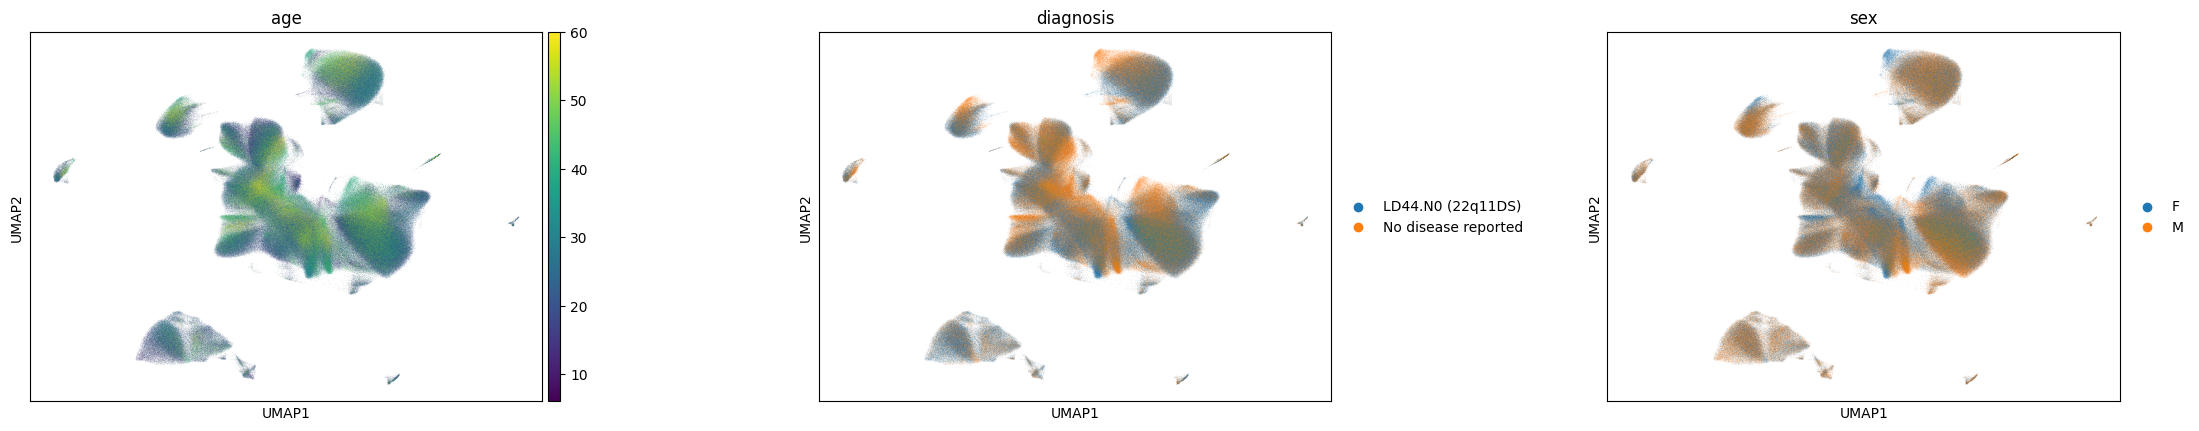

In [42]:
sc.pl.umap(
    adata_full,
    color=["age", "diagnosis", "sex"],
    wspace=0.4,
    ncols=3
)

In [39]:
obs = adata_full.obs.dropna(
    subset=["disease_group", "celltype_l1"]
).copy()

comp = pd.crosstab(
    obs["disease_group"],
    obs["celltype_l1"]
)

comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

comp_pct

celltype_l1,B cells,CD14 Mono,CD16 Mono,CD4 T,CD8 T,DC,NK,Proerythroblast
disease_group,,,,,,,,
Non-patient,5.215422,11.728103,3.418608,36.225635,16.222337,0.685788,26.344038,0.160069
Patient,8.256784,13.821602,3.253351,23.461826,18.085506,0.530171,32.403478,0.187280


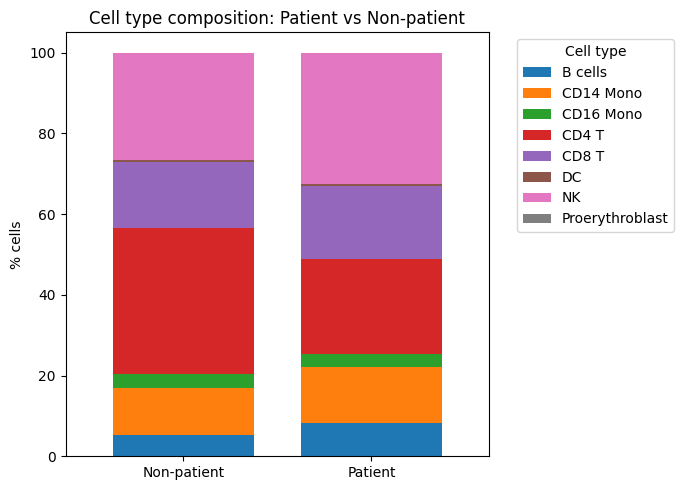

In [41]:
import matplotlib.pyplot as plt
ax = comp_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5),
    width=0.75
)

plt.ylabel("% cells")
plt.xlabel("")
plt.title("Cell type composition: Patient vs Non-patient")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")
plt.xticks(rotation=0)
plt.tight_layout()

In [43]:
adata_full.write_h5ad("adata_no_doublet_withanno.h5ad")

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


1. remove parents
2. check if the age between patient and siblings are comparable
3. down samples to comparable level
4. for each 22q11 genes, calcualte it's expression in across all cell types, compare between patients and siblings. 
5. based on the co-expression of 22q11 genes, set a cut off value, for cells with low value, we keep it for further analysis, while for cells with high score(i.e., these genes are still expressing in cells), we discard them from downstream analysis 

In [5]:
!pwd

/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc


In [6]:
adata_full=sc.read_h5ad("adata_no_doublet_withanno.h5ad")

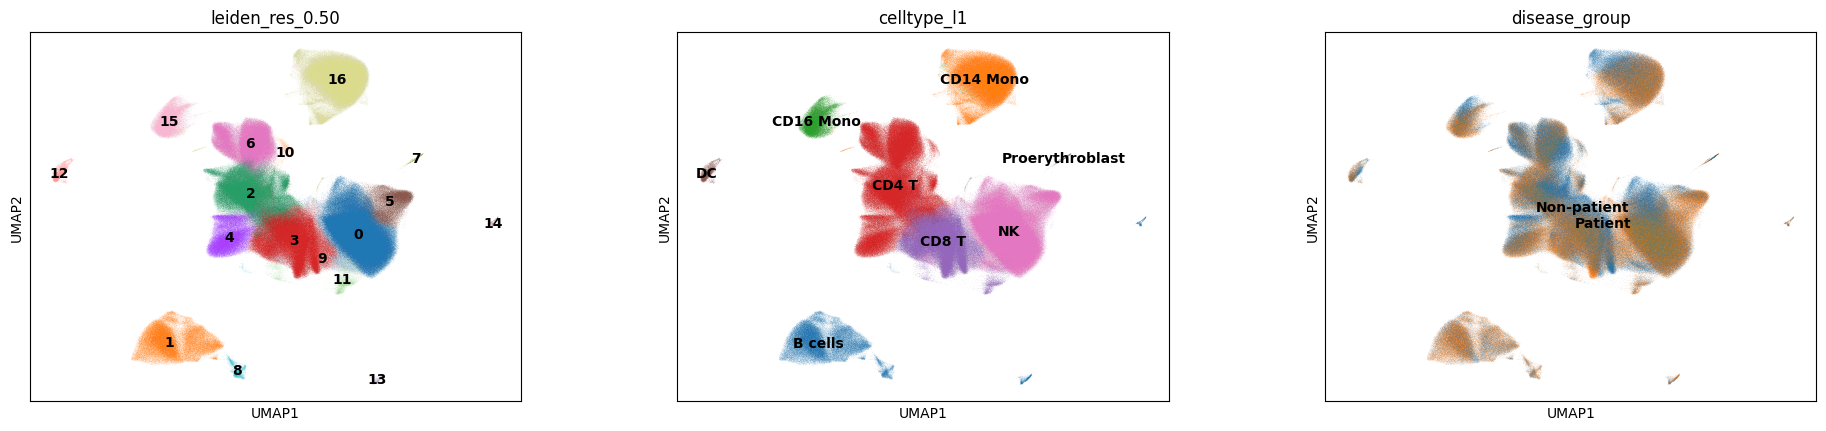

In [47]:
sc.pl.umap(adata_full, color=["leiden_res_0.50", "celltype_l1", "disease_group"], legend_loc="on data", wspace=0.2, ncols=3)

In [51]:
adata_full.obs.columns

Index(['counts', 'genes', 'totalReads', 'countedReads', 'mappedReads',
       'geneReads', 'exonReads', 'intronReads', 'antisenseReads', 'mitoReads',
       'countedMultiGeneReads', 'Saturation', 'mitoProp', 'PCR', 'RT',
       'bead_bc', 'sample', 'flags', 'passing_scaleplex', 'assigned_scaleplex',
       'sample_group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score',
       'predicted_doublet', 'leiden', 'leiden_res_0.07', 'leiden_res_0.50',
       'leiden_res_1.00', 'Mono_score', 'CD4+ T_score', 'CD8+ T_score',
       'NK_score', 'B cells_score', 'DC_score', 'unconventional T_score',
       'Eryth_score', 'HSPC_score', 'ILC_score', 'Platelet_score',
       'celltype_l1', 'Unnamed: 0', 'Date of fixation', 'Unnamed: 2',
       'sample_id', 'barcode', 'sample_type', 'sample_name', 'diagnosis',
       'participant_id', 'age', 'sex', 'ethnic_origi

In [7]:
# Find the relationship column robustly
rel_cols = [c for c in adata_full.obs.columns if "relationship" in c.lower()] # Find columns containing "relationship" (case-insensitive)
print(rel_cols)

rel_col=rel_cols[0] # Use the first matching column as the relationship column

rel = (
    adata_full.obs[rel_col]
    .astype("string")
    .str.lower()
    .str.strip()
) # Standardize the relationship column by converting to string, lowercasing, and stripping whitespace

['Type of relationship (22q participant is the …)']


In [8]:
rel

QSR-1+06+68+03+5C        <NA>
QSR-1+06+49+39+5C        <NA>
QSR-1+06+24+93+5C        <NA>
QSR-1+06+47+63+5C        <NA>
QSR-1+06+56+73+5C        <NA>
                       ...   
QSR-8+93+19+65+4C      sister
QSR-8+93+40+23+4C      sister
QSR-8+93+78+38+4C      sister
QSR-8+93+53+92+4C      sister
QSR-8+93+58+24+4C    daughter
Name: Type of relationship (22q participant is the …), Length: 1111574, dtype: string

In [11]:
import numpy as np
adata_full.obs["family_role"] = np.select( # Assign family roles based on disease group and relationship keywords
    [
        adata_full.obs["disease_group"].eq("Patient"), # Assign "Patient" if the disease group is "Patient"
        rel.str.contains("brother|sister|sibling|sib", na=False), # Assign "Sibling" if the relationship column contains any of the specified sibling keywords
        rel.str.contains("daughter|son|parent", na=False), # Assign "Parent" if the relationship column contains any of the specified parent keywords
    ],
    [
        "Patient",
        "Sibling",
        "Parent",
    ],
    default="Other/unknown control"
)


In [12]:
print(adata_full.obs[["disease_group", rel_col, "family_role"]].drop_duplicates().sort_values("family_role"))

                  disease_group  \
QSR-1+06+30+47+1A   Non-patient   
QSR-1+06+04+41+1A   Non-patient   
QSR-1+06+68+03+5C       Patient   
QSR-1+06+67+92+1A   Non-patient   
QSR-1+06+58+35+1A   Non-patient   

                  Type of relationship (22q participant is the …) family_role  
QSR-1+06+30+47+1A                                        daughter      Parent  
QSR-1+06+04+41+1A                                             son      Parent  
QSR-1+06+68+03+5C                                             NaN     Patient  
QSR-1+06+67+92+1A                                          sister     Sibling  
QSR-1+06+58+35+1A                                         brother     Sibling  


In [17]:
adata_full.write_h5ad("adata_no_doublet_withanno.h5ad")

... storing 'family_role' as categorical
/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
